# Notebook 1: Data Engineering and Feature Pipeline
## AlphaForge AI — A Retrieval-Augmented Framework for Explainable Financial Forecasting and Portfolio Intelligence

**Purpose of this notebook**

This notebook performs:

1. Historical market data collection (via `yfinance`)
2. Data cleaning (missing values, anomaly removal)
3. Feature engineering (returns, technical indicators)
4. Exploratory visualization
5. Export of a clean, feature-rich dataset for Notebook 2 (Forecasting Models) and Notebook 3 (RAG + Agent Pipeline)

**Configuration**

The ticker symbol and date range are defined in a single configuration cell below so that
Notebook 2 and Notebook 3 can reuse the exact same identifiers and file paths. **Do not
change the output file names** if you plan to use the deterministic prompt for Notebook 3.


In [1]:
# 0. Install / Import Dependencies
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn ta --quiet

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Libraries imported successfully.


In [2]:
# 1. Configuration
# These constants are reused across Notebook 1, Notebook 2, and Notebook 3.

TICKER = "AAPL"
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

RAW_DATA_PATH = os.path.join(DATA_DIR, "raw_prices.csv")
PROCESSED_DATA_PATH = os.path.join(DATA_DIR, "processed_features.csv")

print(f"Ticker: {TICKER}")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Raw data will be saved to: {RAW_DATA_PATH}")
print(f"Processed feature dataset will be saved to: {PROCESSED_DATA_PATH}")

Ticker: AAPL
Date range: 2015-01-01 to 2025-01-01
Raw data will be saved to: data\raw_prices.csv
Processed feature dataset will be saved to: data\processed_features.csv


## 2. Data Collection

Download historical OHLCV (Open, High, Low, Close, Volume) data using `yfinance`.

In [3]:
# 2. Download Historical Market Data
raw_df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)

# Flatten multi-index columns if present (newer yfinance versions return MultiIndex)
if isinstance(raw_df.columns, pd.MultiIndex):
    raw_df.columns = raw_df.columns.get_level_values(0)

raw_df.index.name = "Date"
raw_df.to_csv(RAW_DATA_PATH)

print(f"Downloaded {len(raw_df)} rows for {TICKER}")
raw_df.head()

Downloaded 2516 rows for AAPL


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.192596,24.659498,23.754460,24.648434,212818400
2015-01-05,23.511059,24.042132,23.325184,23.962471,257142000
2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400
2015-01-07,23.842972,23.942547,23.610627,23.721267,160423600
2015-01-08,24.759077,24.816610,24.053192,24.170472,237458000


In [4]:
# Basic info about the dataset
print("Shape:", raw_df.shape)
print("\nColumn dtypes:")
print(raw_df.dtypes)
print("\nDate range:", raw_df.index.min(), "to", raw_df.index.max())
print("\nMissing values per column:")
print(raw_df.isna().sum())

Shape: (2516, 5)

Column dtypes:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Date range: 2015-01-02 00:00:00 to 2024-12-31 00:00:00

Missing values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## 3. Data Cleaning

### 3.1 Handling Missing Values

Financial time series can contain missing values due to market holidays, data
provider gaps, or corporate actions. We use forward-fill followed by backward-fill
to preserve the time-series structure (no look-ahead leakage from forward-fill alone
at the very start is handled by the backward-fill on the first rows only).

In [5]:
# 3.1 Handle Missing Values
df = raw_df.copy()

missing_before = df.isna().sum().sum()

# Ensure full business-day index so gaps are explicit, then fill
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="B")
df = df.reindex(full_index)
df.index.name = "Date"

# Forward-fill price/volume columns (carry last known value across non-trading days)
df = df.ffill()
# Backward-fill any remaining NaNs at the very start of the series
df = df.bfill()

missing_after = df.isna().sum().sum()
print(f"Total missing values before: {missing_before}")
print(f"Total missing values after reindex+fill: {missing_after}")
print(f"New shape after reindexing to business days: {df.shape}")

Total missing values before: 0
Total missing values after reindex+fill: 0
New shape after reindexing to business days: (2608, 5)


### 3.2 Anomaly Detection and Removal

We flag and correct extreme single-day returns that are likely data errors
(e.g., erroneous price spikes from data provider glitches) using a z-score
based outlier detection on daily returns. Genuine large market moves
(e.g., during crashes) are typically within a few standard deviations and
are preserved; only extreme statistical outliers (|z| > 6) are treated as
data artifacts and corrected via interpolation.

In [6]:
# 3.2 Anomaly Detection (Z-score on daily returns)
df["Daily_Return"] = df["Close"].pct_change()

z_scores = (df["Daily_Return"] - df["Daily_Return"].mean()) / df["Daily_Return"].std()
ANOMALY_THRESHOLD = 6.0
anomaly_mask = z_scores.abs() > ANOMALY_THRESHOLD

print(f"Number of anomalous data points detected (|z| > {ANOMALY_THRESHOLD}): {anomaly_mask.sum()}")

if anomaly_mask.sum() > 0:
    print(df.loc[anomaly_mask, ["Close", "Daily_Return"]])
    # Replace anomalous closing prices with NaN, then interpolate
    df.loc[anomaly_mask, "Close"] = np.nan
    df["Close"] = df["Close"].interpolate(method="linear")
    # Recompute dependent columns
    df["Daily_Return"] = df["Close"].pct_change()
    print("Anomalies corrected via linear interpolation.")
else:
    print("No anomalies detected — data appears clean.")

df["Daily_Return"] = df["Daily_Return"].fillna(0)

Number of anomalous data points detected (|z| > 6.0): 2
Price           Close  Daily_Return
Date                               
2020-03-13  67.102928      0.119808
2020-03-16  58.470341     -0.128647
Anomalies corrected via linear interpolation.


## 4. Feature Engineering

We compute a comprehensive set of features used by the forecasting models in
Notebook 2:

- **Return-based features**: daily return, log return, multi-day momentum
- **Trend indicators**: Simple Moving Averages (SMA), Exponential Moving Averages (EMA), MACD
- **Momentum indicators**: RSI (Relative Strength Index)
- **Volatility indicators**: Rolling standard deviation, Bollinger Bands, ATR (Average True Range)
- **Volume-based features**: Volume change, On-Balance Volume (OBV)
- **Target variable**: Next-day closing price and next-day direction (for directional accuracy evaluation)

In [7]:
# 4.1 Return-Based Features
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
df["Momentum_5"] = df["Close"].pct_change(5)
df["Momentum_10"] = df["Close"].pct_change(10)

df.head()

Price,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Momentum_5,Momentum_10
Date,,,,,,,,,
2015-01-02,24.192596,24.659498,23.754460,24.648434,212818400.0,0.000000,NaN,NaN,NaN
2015-01-05,23.511059,24.042132,23.325184,23.962471,257142000.0,-0.028171,-0.028576,NaN,NaN
2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400.0,0.000094,0.000094,NaN,NaN
2015-01-07,23.842972,23.942547,23.610627,23.721267,160423600.0,0.014022,0.013924,NaN,NaN
2015-01-08,24.759077,24.816610,24.053192,24.170472,237458000.0,0.038422,0.037703,NaN,NaN


In [8]:
# 4.2 Trend Indicators: SMA, EMA, MACD
# Simple Moving Averages
df["SMA_10"] = df["Close"].rolling(window=10).mean()
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

# Exponential Moving Averages
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

# MACD = EMA_12 - EMA_26 ; Signal line = EMA_9 of MACD
df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

In [9]:
# 4.3 Momentum Indicator: RSI (14-day)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["RSI_14"] = compute_rsi(df["Close"], period=14)

In [10]:
# 4.4 Volatility Indicators: Rolling Std, Bollinger Bands, ATR
# Rolling volatility of daily returns
df["Volatility_10"] = df["Daily_Return"].rolling(window=10).std()
df["Volatility_20"] = df["Daily_Return"].rolling(window=20).std()

# Bollinger Bands (20-day, 2 std)
bb_window = 20
bb_std_mult = 2
df["BB_Mid"] = df["Close"].rolling(window=bb_window).mean()
bb_std = df["Close"].rolling(window=bb_window).std()
df["BB_Upper"] = df["BB_Mid"] + bb_std_mult * bb_std
df["BB_Lower"] = df["BB_Mid"] - bb_std_mult * bb_std
df["BB_Width"] = (df["BB_Upper"] - df["BB_Lower"]) / df["BB_Mid"]

# Average True Range (ATR, 14-day)
high_low = df["High"] - df["Low"]
high_close = (df["High"] - df["Close"].shift(1)).abs()
low_close = (df["Low"] - df["Close"].shift(1)).abs()
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df["ATR_14"] = true_range.rolling(window=14).mean()

In [11]:
# 4.5 Volume-Based Features
df["Volume_Change"] = df["Volume"].pct_change()

# On-Balance Volume (OBV)
obv = [0]
close_vals = df["Close"].values
vol_vals = df["Volume"].values
for i in range(1, len(df)):
    if close_vals[i] > close_vals[i - 1]:
        obv.append(obv[-1] + vol_vals[i])
    elif close_vals[i] < close_vals[i - 1]:
        obv.append(obv[-1] - vol_vals[i])
    else:
        obv.append(obv[-1])
df["OBV"] = obv

In [12]:
# 4.6 Target Variables (for Notebook 2)
# Regression target: next trading day's closing price
df["Target_Close_Next"] = df["Close"].shift(-1)

# Classification / directional target: 1 if next day's close is higher, else 0
df["Target_Direction"] = (df["Target_Close_Next"] > df["Close"]).astype(int)

In [13]:
# 4.7 Drop rows with NaNs introduced by rolling windows / shifts
print("Shape before dropping NaNs:", df.shape)
df_clean = df.dropna().copy()
print("Shape after dropping NaNs:", df_clean.shape)
print("\nRemaining missing values:", df_clean.isna().sum().sum())
df_clean.head()

Shape before dropping NaNs: (2608, 29)
Shape after dropping NaNs: (2558, 29)

Remaining missing values: 0


Price,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Momentum_5,Momentum_10,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,MACD,MACD_Signal,MACD_Hist,RSI_14,Volatility_10,Volatility_20,BB_Mid,BB_Upper,BB_Lower,BB_Width,ATR_14,Volume_Change,OBV,Target_Close_Next,Target_Direction
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-03-12,27.647055,27.747025,27.020581,27.171645,193450800.0,0.018079,0.017918,-0.015505,-0.045775,28.142453,28.433917,26.467108,28.030049,27.743203,0.286846,0.574464,-0.287618,39.017061,0.012758,0.013433,28.433917,29.551862,27.315973,0.078635,0.652974,-0.298471,3.690981e+09,27.455996,0
2015-03-13,27.455996,27.858095,27.231621,27.635941,207309200.0,-0.006911,-0.006935,-0.023776,-0.037911,28.034263,28.395151,26.532376,27.941733,27.721929,0.219805,0.503532,-0.283728,26.879576,0.012270,0.013433,28.395151,29.593552,27.196751,0.084409,0.642184,0.071638,3.483672e+09,27.758131,1
2015-03-16,27.758131,27.758131,27.296052,27.520426,143497200.0,0.011004,0.010944,-0.017225,-0.032070,27.942293,28.371492,26.617317,27.913487,27.724610,0.188877,0.440601,-0.251725,32.710801,0.012886,0.013712,28.371492,29.601771,27.141213,0.086726,0.636629,-0.307811,3.627169e+09,28.222429,1
2015-03-17,28.222429,28.284632,27.913636,27.969174,204092400.0,0.016727,0.016588,0.020320,-0.017935,27.890753,28.362717,26.711500,27.961016,27.761486,0.199531,0.392387,-0.192856,45.533498,0.014304,0.014193,28.362717,29.594705,27.130730,0.086874,0.610447,0.422274,3.831262e+09,28.540112,1
2015-03-18,28.540112,28.693398,28.073589,28.213545,261083600.0,0.011256,0.011193,0.050966,-0.000544,27.889198,28.359941,26.805443,28.050108,27.819162,0.230946,0.360099,-0.129153,44.971759,0.014748,0.014339,28.359941,29.589967,27.129915,0.086744,0.587121,0.279242,4.092345e+09,28.324619,0


## 5. Exploratory Visualization

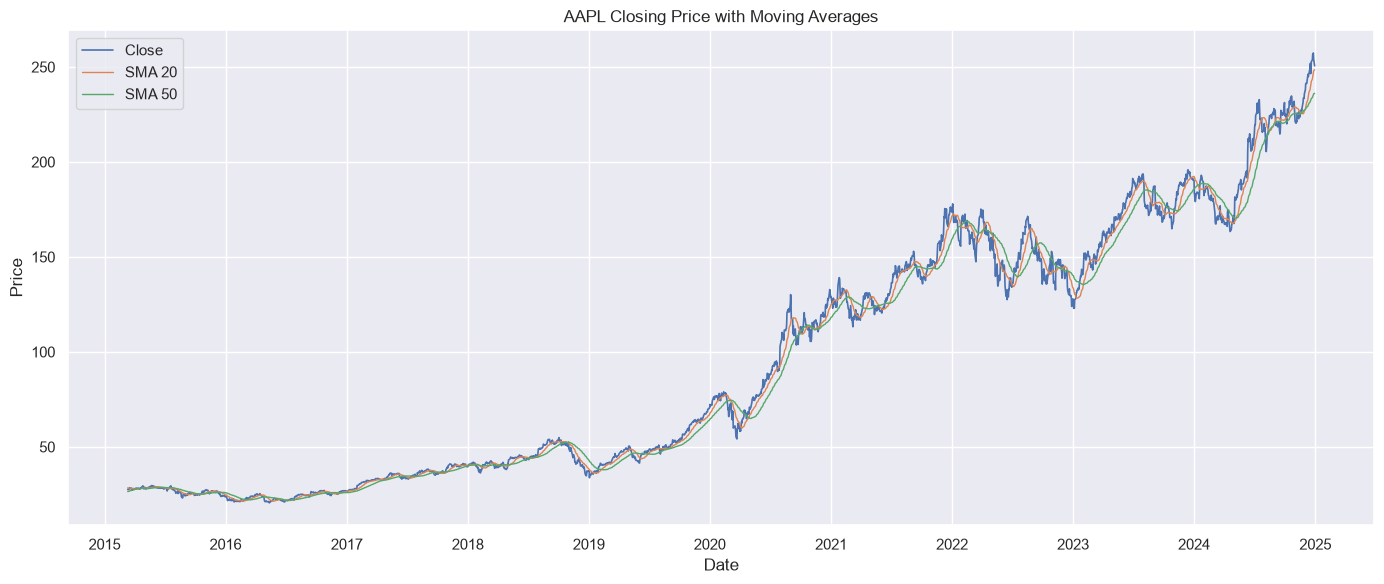

In [14]:
# 5.1 Price Series with Moving Averages
plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean["Close"], label="Close", linewidth=1.2)
plt.plot(df_clean.index, df_clean["SMA_20"], label="SMA 20", linewidth=1)
plt.plot(df_clean.index, df_clean["SMA_50"], label="SMA 50", linewidth=1)
plt.title(f"{TICKER} Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

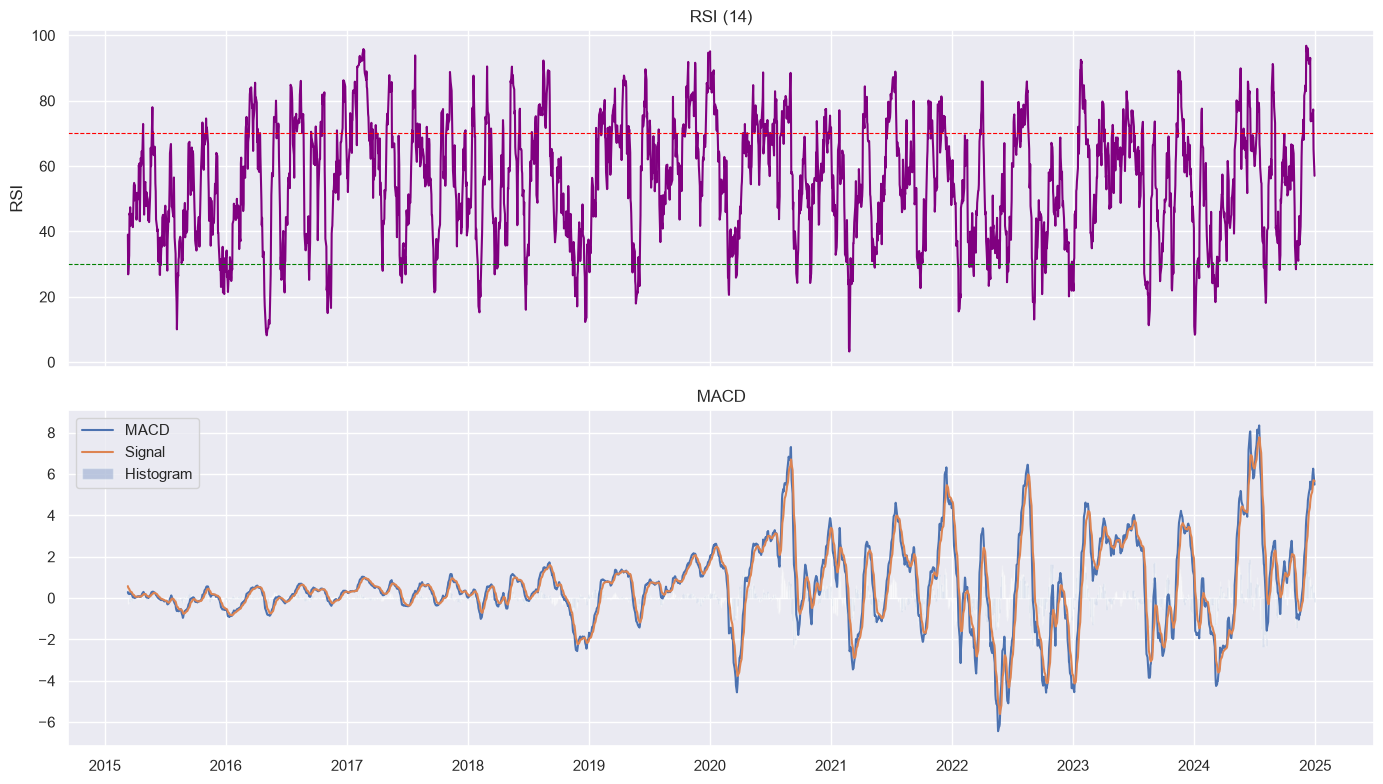

In [15]:
# 5.2 RSI and MACD
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_clean.index, df_clean["RSI_14"], color="purple")
axes[0].axhline(70, color="red", linestyle="--", linewidth=0.8)
axes[0].axhline(30, color="green", linestyle="--", linewidth=0.8)
axes[0].set_title("RSI (14)")
axes[0].set_ylabel("RSI")

axes[1].plot(df_clean.index, df_clean["MACD"], label="MACD")
axes[1].plot(df_clean.index, df_clean["MACD_Signal"], label="Signal")
axes[1].bar(df_clean.index, df_clean["MACD_Hist"], label="Histogram", alpha=0.3)
axes[1].set_title("MACD")
axes[1].legend()

plt.tight_layout()
plt.show()

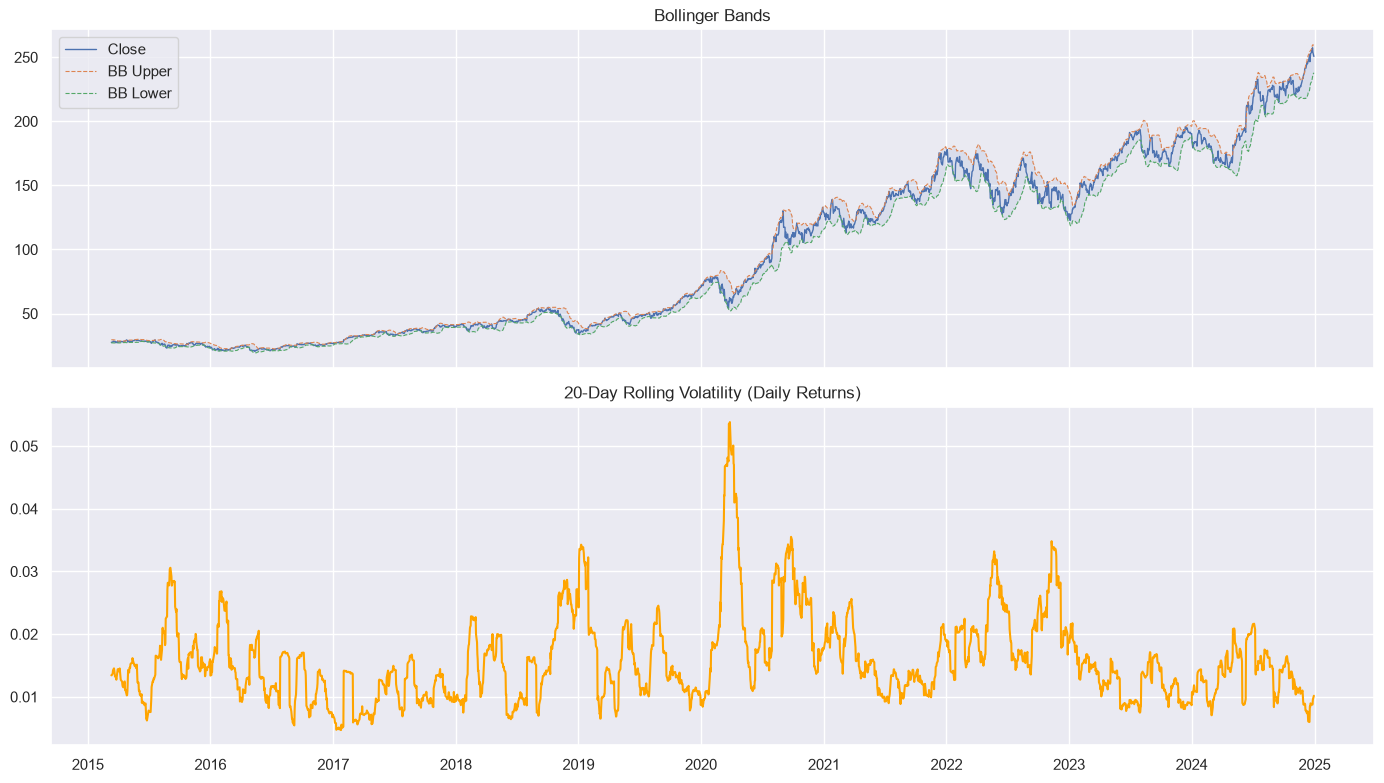

In [16]:
# 5.3 Volatility and Bollinger Bands
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_clean.index, df_clean["Close"], label="Close", linewidth=1)
axes[0].plot(df_clean.index, df_clean["BB_Upper"], label="BB Upper", linestyle="--", linewidth=0.8)
axes[0].plot(df_clean.index, df_clean["BB_Lower"], label="BB Lower", linestyle="--", linewidth=0.8)
axes[0].fill_between(df_clean.index, df_clean["BB_Lower"], df_clean["BB_Upper"], alpha=0.1)
axes[0].set_title("Bollinger Bands")
axes[0].legend()

axes[1].plot(df_clean.index, df_clean["Volatility_20"], color="orange")
axes[1].set_title("20-Day Rolling Volatility (Daily Returns)")

plt.tight_layout()
plt.show()

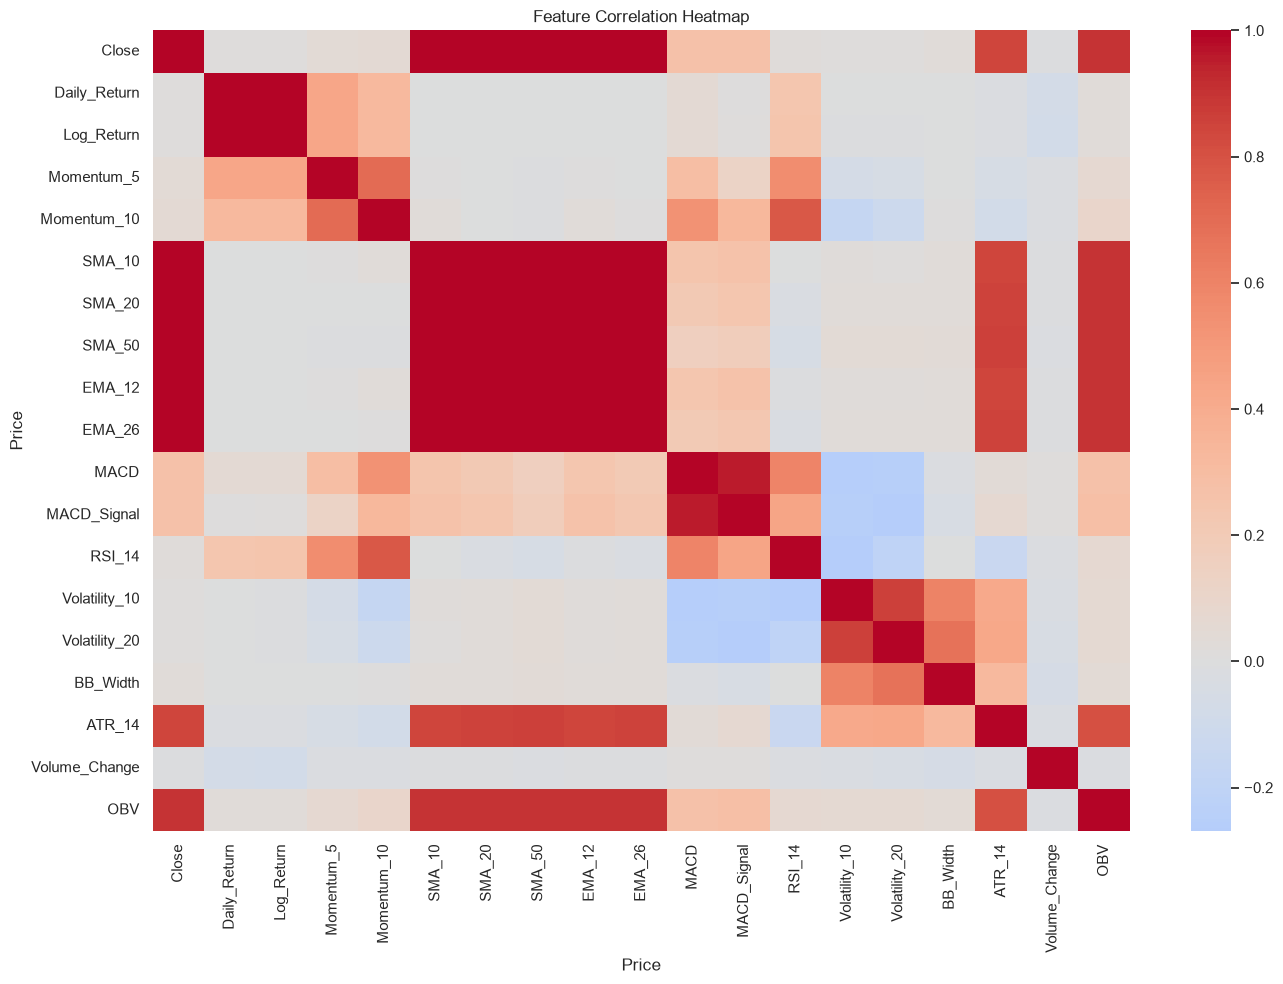

In [18]:
# 5.4 Feature Correlation Heatmap
feature_cols = [
    "Close", "Daily_Return", "Log_Return", "Momentum_5", "Momentum_10",
    "SMA_10", "SMA_20", "SMA_50", "EMA_12", "EMA_26",
    "MACD", "MACD_Signal", "RSI_14",
    "Volatility_10", "Volatility_20", "BB_Width", "ATR_14",
    "Volume_Change", "OBV"
]

plt.figure(figsize=(14, 10))
corr = df_clean[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

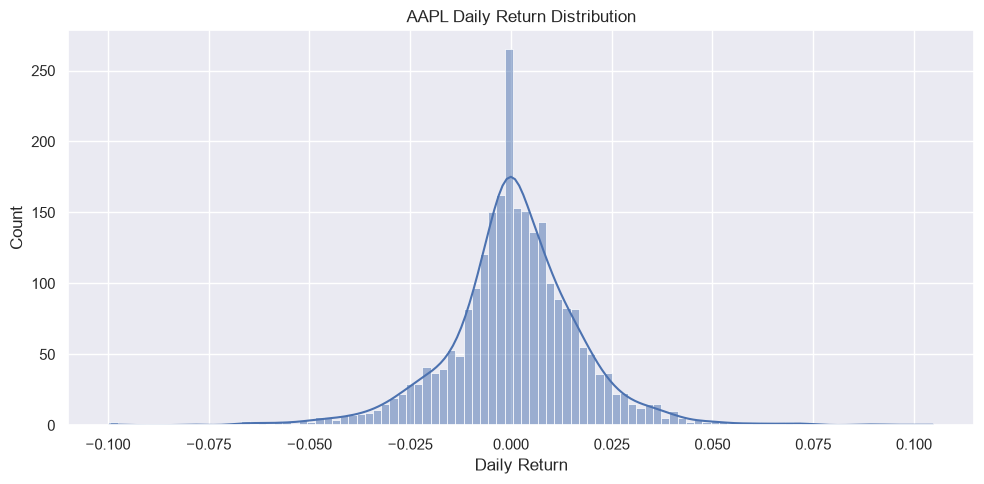

Daily return statistics:
count    2558.000000
mean        0.001018
std         0.017242
min        -0.099607
25%        -0.006727
50%         0.000424
75%         0.009619
max         0.104689
Name: Daily_Return, dtype: float64


In [17]:
# 5.5 Distribution of Daily Returns
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["Daily_Return"], bins=100, kde=True)
plt.title(f"{TICKER} Daily Return Distribution")
plt.xlabel("Daily Return")
plt.tight_layout()
plt.show()

print("Daily return statistics:")
print(df_clean["Daily_Return"].describe())

## 6. Export Processed Dataset

The processed feature dataset is saved to `data/processed_features.csv`. This file is the
**required input for Notebook 2** (Financial Forecasting Models) and is referenced
by name in the Notebook 3 prompt.

In [19]:
# 6. Save Processed Dataset
df_clean.to_csv(PROCESSED_DATA_PATH)
print(f"Processed dataset saved to: {PROCESSED_DATA_PATH}")
print(f"Final shape: {df_clean.shape}")
print(f"\nColumns: {list(df_clean.columns)}")

Processed dataset saved to: data\processed_features.csv
Final shape: (2558, 29)

Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Log_Return', 'Momentum_5', 'Momentum_10', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI_14', 'Volatility_10', 'Volatility_20', 'BB_Mid', 'BB_Upper', 'BB_Lower', 'BB_Width', 'ATR_14', 'Volume_Change', 'OBV', 'Target_Close_Next', 'Target_Direction']


## 7. Summary

- Downloaded daily OHLCV data for the configured **TICKER** over the configured date range.
- Reindexed to a continuous business-day calendar and filled missing values.
- Detected and corrected statistical price anomalies (|z| > 6 on daily returns).
- Engineered features spanning return, trend, momentum, volatility, and volume categories.
- Created regression (`Target_Close_Next`) and classification (`Target_Direction`) targets.
- Exported a clean dataset to `data/processed_features.csv` for use in Notebook 2.

**Next step:** Proceed to **Notebook 2 — Financial Forecasting Models**, which loads
`data/processed_features.csv`, trains XGBoost and LSTM models, and evaluates them
using RMSE, MAE, Directional Accuracy, and Sharpe Ratio.